# SentiSense — Analysis, Modeling & Explainability

End-to-end analysis of the SentiSense pipeline: coverage → features → embeddings →
baselines → LSTM tuning → holdout → strategy performance, with visualizations and
explainability. Reuses the `sentisense` package.

Validation uses train-only scaling/PCA, chronological / TimeSeriesSplit splits, and a
held-out test window.

## Prerequisites
```bash
uv sync --extra ml --extra embed --extra finance --extra notebook   # at repo root
# .env has the DB URL + local LLM backend
```
Heavy deps (shap, umap, seaborn) lazy-install in §0 if missing.

## Sections
0. Setup · 1. Coverage & EDA · 2. Features · 3. Embeddings & clustering ·
4. Baselines + SHAP/permutation · 5. LSTM tuning · 6. Holdout (ROC / calibration / confusion) ·
6b. Full-period performance · 7. Strategy equity curve · 8. Summary

## 0. Setup

In [31]:
# Lazy-install analysis/explainability extras if absent (heavy; not in base env).
import importlib, subprocess, sys
for pkg, imp in [("shap", "shap"), ("umap-learn", "umap"), ("seaborn", "seaborn")]:
    if importlib.util.find_spec(imp) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)


In [32]:
from __future__ import annotations
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

import sentisense  # loads .env
from sentisense.db import get_engine, get_connection_url
from sentisense.constants import CUTOFF_DATE

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
engine = get_engine()
print("DB:", get_connection_url().rsplit("@", 1)[-1])
print("Cutoff:", CUTOFF_DATE)


def feat_family(col: str) -> str:
    """Bucket a feature column into its signal source (for grouped explainability)."""
    if col.startswith(("mean_", "ix_")) or col == "n_headlines":
        return "news"
    if col.startswith(("SP500_", "VIX_", "Brent_", "USDILS_", "VTA35_", "Market_", "FX_")):
        return "cross_asset"
    if col.startswith(("TA125_", "DoW_")):
        return "technical"
    return "other"


DB: localhost:5432/sentisense
Cutoff: 2023-10-07


## 1. Coverage & EDA
Corpus reach, per-model scored breakdown, monthly volume.

,model_name,validated,total
0,mistral-small-4,2950339,2951625
1,mistral-small:latest,52640,61645


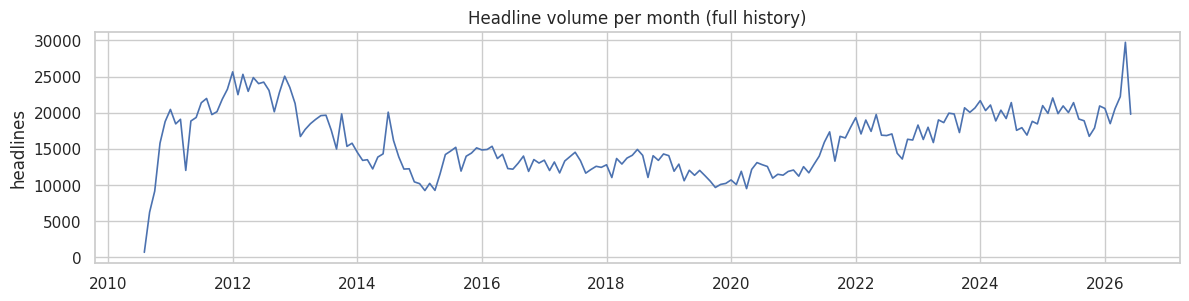

date span: 2010-08 → 2026-06


In [33]:
models = pd.read_sql(text('''
    SELECT nv.model_name,
           COUNT(*) FILTER (WHERE nv.validation_passed) AS validated,
           COUNT(*) AS total
    FROM nlp_vectors nv JOIN raw_headlines rh ON rh.id = nv.headline_id
    GROUP BY nv.model_name ORDER BY validated DESC
'''), engine)
display(models)

monthly = pd.read_sql(text('''
    SELECT to_char(date_trunc('month', date), 'YYYY-MM') AS month, COUNT(*) AS raw
    FROM raw_headlines GROUP BY 1 ORDER BY 1
'''), engine)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(pd.to_datetime(monthly["month"]), monthly["raw"], lw=1.2)
ax.set_title("Headline volume per month (full history)"); ax.set_ylabel("headlines"); plt.show()
print("date span:", monthly["month"].iloc[0], "→", monthly["month"].iloc[-1])


## 2. Features
Build the leak-safe daily frames. Inspect feature groups + correlations + target balance over time.

In [34]:
from sentisense.features import build_datasets
mt, ml = build_datasets(engine)   # daily-mean (tree shape), per-source (LSTM shape)
print("mt (daily-mean):", mt.shape, "| ml (per-source):", ml.shape)
print("target +rate:", f"{mt['Target'].mean():.3f}")

fam_counts = pd.Series([feat_family(c) for c in mt.columns if c != "Target"]).value_counts()
print("feature families:", fam_counts.to_dict())


2026-06-20 12:41:19.859 | INFO     | sentisense.features.dataset:_load_raw_scores:78 - Loaded 2,401,366 validated headlines (<= 2023-10-07), 59 sources, models=['mistral-small-4', 'mistral-small:latest']
2026-06-20 12:41:21.124 | INFO     | sentisense.features.dataset:build_datasets:403 - Datasets built (<= 2023-10-07): mt=(1914, 64), ml=(1914, 160)
2026-06-20 12:41:21.124 | INFO     | sentisense.features.dataset:build_datasets:404 -   trading-day rows: mt=1,914, ml=1,914  (LSTM-viability bar ~750)


mt (daily-mean): (1914, 64) | ml (per-source): (1914, 160)
target +rate: 0.531
feature families: {'cross_asset': 31, 'technical': 18, 'news': 14}


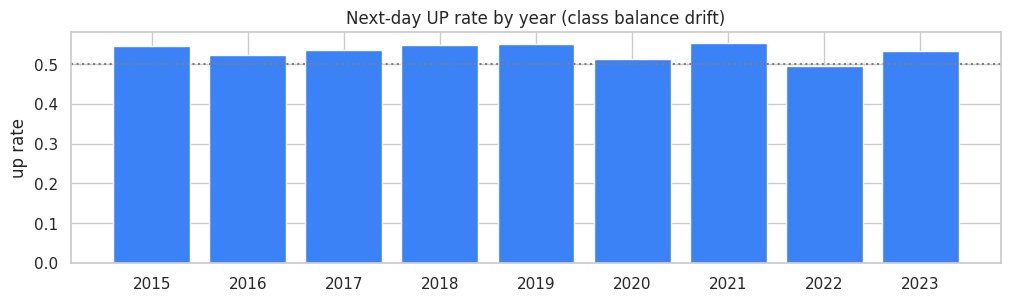

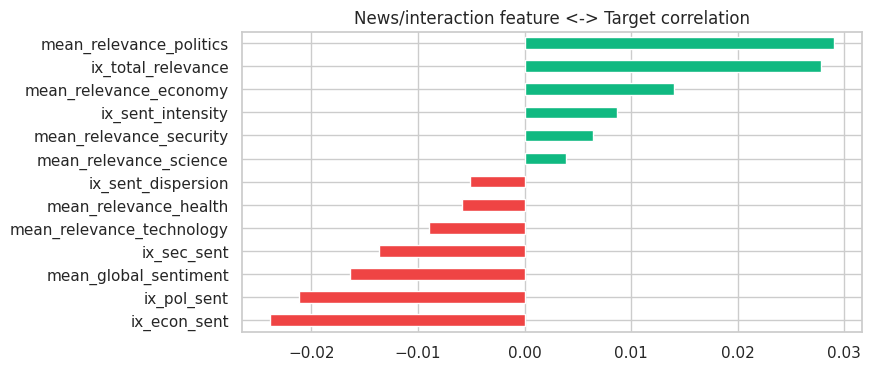

In [35]:
# Target rate by year — is the up/down balance stable, or regime-drifting?
yr = mt.assign(year=mt.index.year).groupby("year")["Target"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(yr.index.astype(str), yr["mean"], color="#3b82f6"); ax.axhline(0.5, ls=":", c="gray")
ax.set_title("Next-day UP rate by year (class balance drift)"); ax.set_ylabel("up rate"); plt.show()

# Correlation of the news + interaction features with the target.
news_ix = [c for c in mt.columns if c.startswith(("mean_", "ix_"))]
corr = mt[news_ix + ["Target"]].corr()["Target"].drop("Target").sort_values()
fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(corr))))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#10b981", "#ef4444"))
ax.set_title("News/interaction feature <-> Target correlation"); plt.show()


## 3. Embeddings & narrative clustering
2-D map of daily e5 centroids colored by next-day direction; dominant-cluster-ratio over time.

cached embeddings: 2401552 dim: 768


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


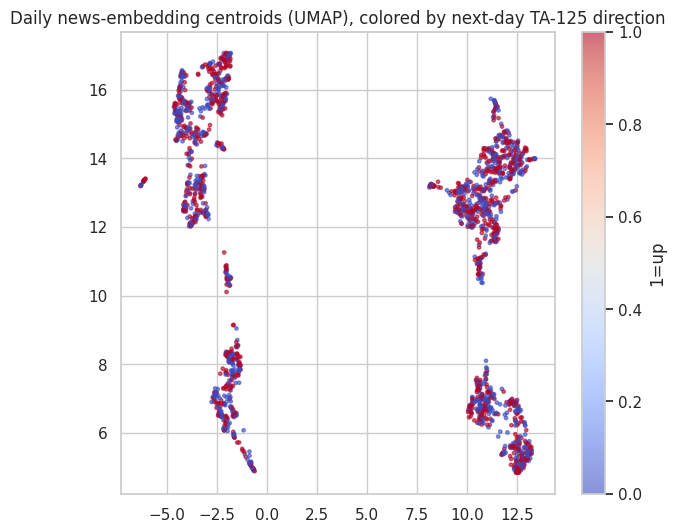

In [36]:
from sentisense.embed import load_embeddings
meta, vecs = load_embeddings(engine)
print("cached embeddings:", len(meta), "dim:", (vecs.shape[1] if vecs.size else 0))
if vecs.size:
    # daily centroid -> UMAP 2-D, colored by that day's next-day direction
    cen = pd.DataFrame(vecs, index=pd.to_datetime(meta["date"].values)).groupby(level=0).mean()
    common = cen.index.intersection(mt.index)
    import umap
    emb2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(cen.loc[common].values)
    lab = mt.loc[common, "Target"].values
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(emb2d[:, 0], emb2d[:, 1], c=lab, cmap="coolwarm", s=6, alpha=0.6)
    ax.set_title("Daily news-embedding centroids (UMAP), colored by next-day TA-125 direction")
    plt.colorbar(sc, label="1=up"); plt.show()
else:
    print("No embeddings yet — run the embed stage first.")


2026-06-20 12:48:22.852 | INFO     | sentisense.cluster.narrative:build_narrative_features:87 - Narrative features built for 4,788 days (k=8, refit_every=30).


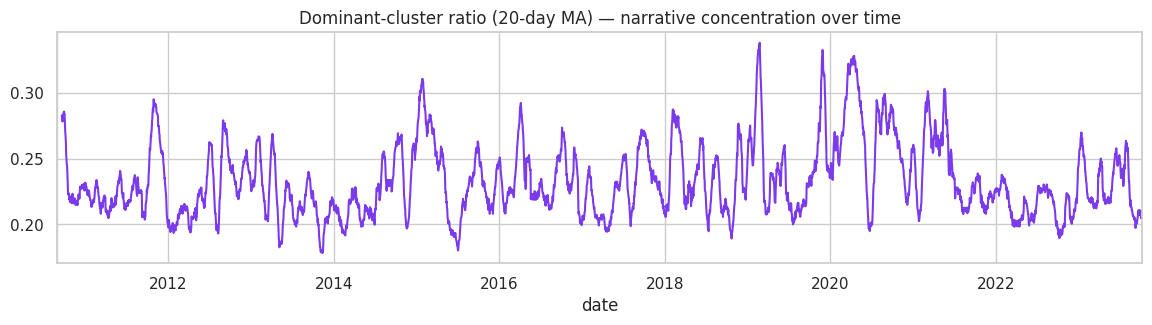

,dominant_cluster_ratio,cluster_entropy,narrative_n_headlines
count,4787.000000,4787.000000,4788.000000
mean,0.233157,0.940130,501.577277
std,0.043491,0.035378,194.632625
min,0.133758,0.724007,3.000000
25%,0.202653,0.922277,351.000000
50%,0.225000,0.947704,487.000000
75%,0.255157,0.965685,626.000000
max,0.666667,0.998474,1207.000000


In [37]:
from sentisense.cluster import build_narrative_features
nf = build_narrative_features(engine)
if nf is not None and not nf.empty:
    fig, ax = plt.subplots(figsize=(14, 3))
    nf["dominant_cluster_ratio"].rolling(20).mean().plot(ax=ax, color="#7c3aed")
    ax.set_title("Dominant-cluster ratio (20-day MA) — narrative concentration over time"); plt.show()
    display(nf.describe())
else:
    print("No narrative features — run the embed stage first.")


## 4. Baselines + explainability
Naive (majority/persistence) + XGBoost on TimeSeriesSplit, then **SHAP** + **permutation
importance** on the tree to see *which feature families actually drive it* — news vs
cross-asset vs technicals. This is the honest "does the news signal earn its place?" check.

In [38]:
from sentisense.models.baselines import run_baselines
res = run_baselines(mt)
display(pd.DataFrame(res).T)


2026-06-20 12:48:23.671 | INFO     | sentisense.models.baselines:run_baselines:95 - Phase 5 baselines:
2026-06-20 12:48:23.672 | INFO     | sentisense.models.baselines:run_baselines:97 -   MajorityClass    acc=0.4913 balacc=0.5000 f1=0.3294 auc=0.5000 mcc=0.0000
2026-06-20 12:48:23.672 | INFO     | sentisense.models.baselines:run_baselines:97 -   Persistence      acc=0.5087 balacc=0.5086 f1=0.5086 auc=0.5086 mcc=0.0172
2026-06-20 12:48:23.673 | INFO     | sentisense.models.baselines:run_baselines:97 -   XGBoost_TSCV     acc=0.5304 balacc=0.5260 f1=0.5227 auc=0.5157 mcc=0.0530


,accuracy,balanced_accuracy,f1,mcc,roc_auc
MajorityClass,0.491289,0.500000,0.329439,0.000000,0.500000
Persistence,0.508711,0.508622,0.508615,0.017243,0.508622
XGBoost_TSCV,0.530408,0.525955,0.522708,0.053012,0.515716


/tmp/ipykernel_1945018/1684585309.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xte, max_display=20, show=True)


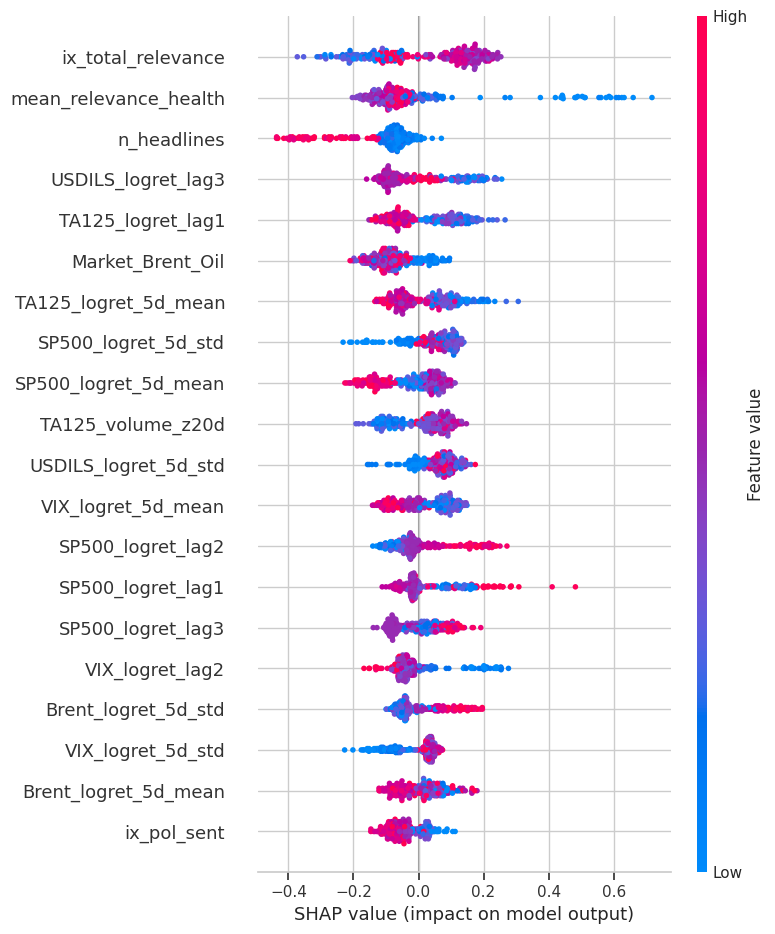

In [39]:
# Fit one XGBoost on a chronological train slice for explainability.
# (Trees need no scaling, and SHAP wants NAMED features — so we slice mt directly
#  rather than chronological_split, which returns scaled, unnamed arrays.)
import xgboost as xgb
y = mt["Target"].values.astype(int); X = mt.drop(columns=["Target"])
n = len(mt); ntr = int(n * 0.7); nva = int(n * 0.15)
Xtr, ytr = X.iloc[:ntr], y[:ntr]
Xte, yte = X.iloc[ntr + nva:], y[ntr + nva:]
pos = max(int(ytr.sum()), 1); neg = max(len(ytr) - int(ytr.sum()), 1)
clf = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.03,
                        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=neg / pos,
                        eval_metric="logloss", random_state=42, verbosity=0)
clf.fit(Xtr, ytr)

import shap
expl = shap.TreeExplainer(clf)
sv = expl.shap_values(Xte)
shap.summary_plot(sv, Xte, max_display=20, show=True)


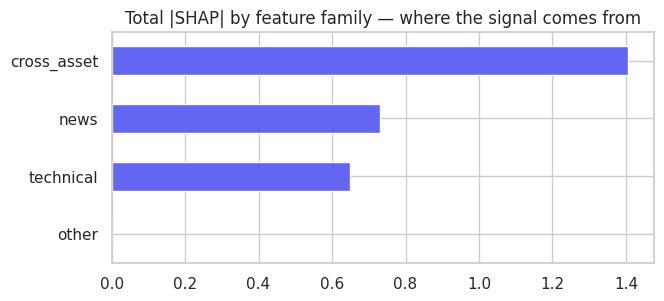

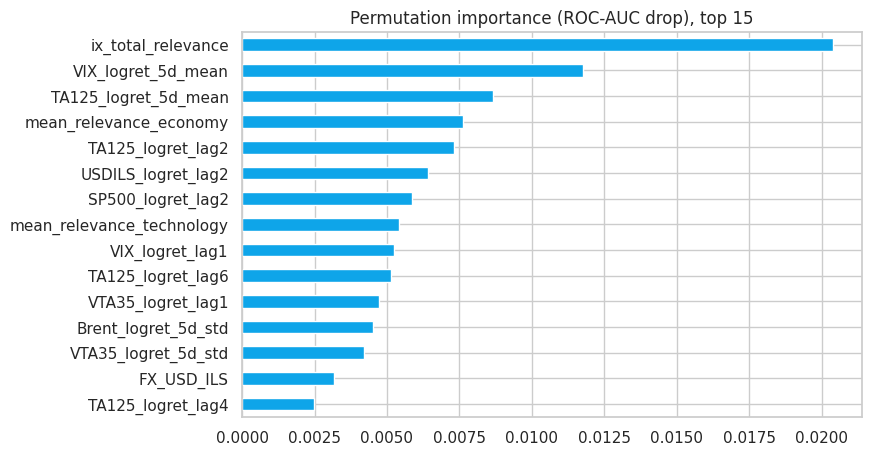

In [40]:
# Aggregate SHAP by feature FAMILY -> which signal source matters most.
absmean = np.abs(sv).mean(axis=0)
fam = {"news": 0.0, "cross_asset": 0.0, "technical": 0.0, "other": 0.0}
for col, v in zip(Xte.columns, absmean):
    fam[feat_family(col)] += v
fam = pd.Series(fam).sort_values()
fig, ax = plt.subplots(figsize=(7, 3)); fam.plot.barh(ax=ax, color="#6366f1")
ax.set_title("Total |SHAP| by feature family — where the signal comes from"); plt.show()

from sklearn.inspection import permutation_importance
pi = permutation_importance(clf, Xte, yte, n_repeats=10, random_state=42, scoring="roc_auc")
imp = pd.Series(pi.importances_mean, index=Xte.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5)); imp[::-1].plot.barh(ax=ax, color="#0ea5e9")
ax.set_title("Permutation importance (ROC-AUC drop), top 15"); plt.show()


## 5. LSTM tuning — Optuna visualizations
Loads the persisted studies (score-LSTM + embedding-LSTM) from the project DB. If none
exist yet, runs a SHORT demo search so the plots render. The full HPO is the long
headless `tune` stage.

In [41]:
import os
import optuna
from sentisense.hpo.optuna_lstm import STUDY_SCORES, has_completed_trials
storage = get_connection_url()


def load_or_none(name):
    try:
        s = optuna.load_study(study_name=name, storage=storage)
        return s if has_completed_trials(s) else None
    except Exception:
        return None


study = load_or_none(STUDY_SCORES)
if study is None:
    print("No completed score-LSTM study found — running a SHORT demo (5 trials)…")
    from sentisense.hpo import run_hpo
    os.environ["SENTISENSE_OPTUNA_TRIALS"] = "5"
    study = run_hpo(ml, n_trials=5, study_name="demo_scores")
print("best value:", round(study.best_value, 4))
print("best params:", study.best_params)


best value: 0.538
best params: {'window': 30, 'units': 44, 'n_layers': 2, 'bidirectional': False, 'd_dense': 16, 'dropout': 0.28462847799398566, 'recurrent_dropout': 0.38219428608768036, 'weight_decay': 8.67829240088232e-05, 'grad_clip': 5.0, 'dense_act': 'tanh', 'pooling': 'last', 'lr': 0.003744348639602507, 'batch_size': 32}


/tmp/ipykernel_1945018/2916198123.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study); plt.title("Optuna optimization history (val ROC-AUC)"); plt.show()


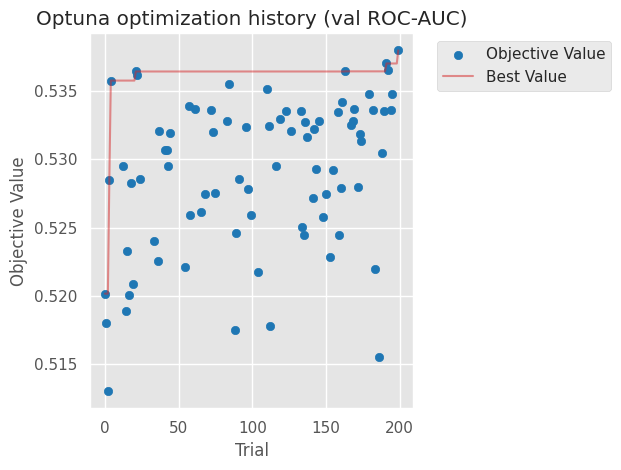

/tmp/ipykernel_1945018/2916198123.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study); plt.title("Hyperparameter importances"); plt.show()


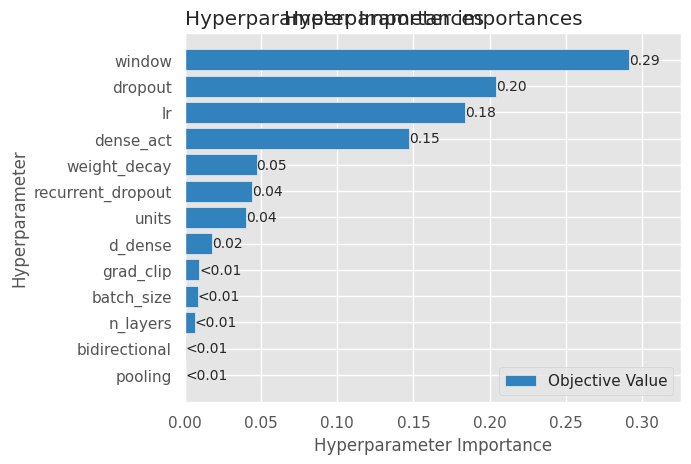

In [42]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
plot_optimization_history(study); plt.title("Optuna optimization history (val ROC-AUC)"); plt.show()
plot_param_importances(study); plt.title("Hyperparameter importances"); plt.show()


## 6. Holdout evaluation + explainability
Sacred-test metrics for the score-LSTM (calibrated + threshold-tuned), ROC, a
**reliability (calibration) diagram**, and the confusion matrix.

In [43]:
from sentisense.hpo import final_holdout_eval
summary_s, proba_s, labels_s = final_holdout_eval(ml, study.best_params, n_seeds=2)
display(pd.DataFrame(summary_s).T)


2026-06-20 12:48:27.985 | INFO     | sentisense.models.train:train_model:109 - Early stopping at epoch 19 (lstm_final_s42).
2026-06-20 12:48:29.778 | INFO     | sentisense.models.train:train_model:109 - Early stopping at epoch 18 (lstm_final_s123).
2026-06-20 12:48:29.985 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:298 - Phase 7 holdout (mean±std over 2 seeds):
2026-06-20 12:48:29.985 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   accuracy@0.5           0.5000 ± 0.0058
2026-06-20 12:48:29.986 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   balanced_accuracy@0.5  0.5001 ± 0.0057
2026-06-20 12:48:29.986 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   f1@0.5                 0.4990 ± 0.0066
2026-06-20 12:48:29.986 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   roc_auc@0.5            0.5088 ± 0.0144
2026-06-20 12:48:29.987 | INFO     | sentisense.hpo.optuna_lstm:final_holdout_eval:300 -   mcc@0.5   

,mean,std
accuracy@0.5,0.500000,0.005837
balanced_accuracy@0.5,0.500076,0.005678
f1@0.5,0.499001,0.006566
roc_auc@0.5,0.508812,0.014444
mcc@0.5,0.000115,0.011402
accuracy@tuned,0.496109,0.013619
balanced_accuracy@tuned,0.497441,0.013914
f1@tuned,0.425228,0.018305
roc_auc@tuned,0.507177,0.007964
mcc@tuned,0.001257,0.040197


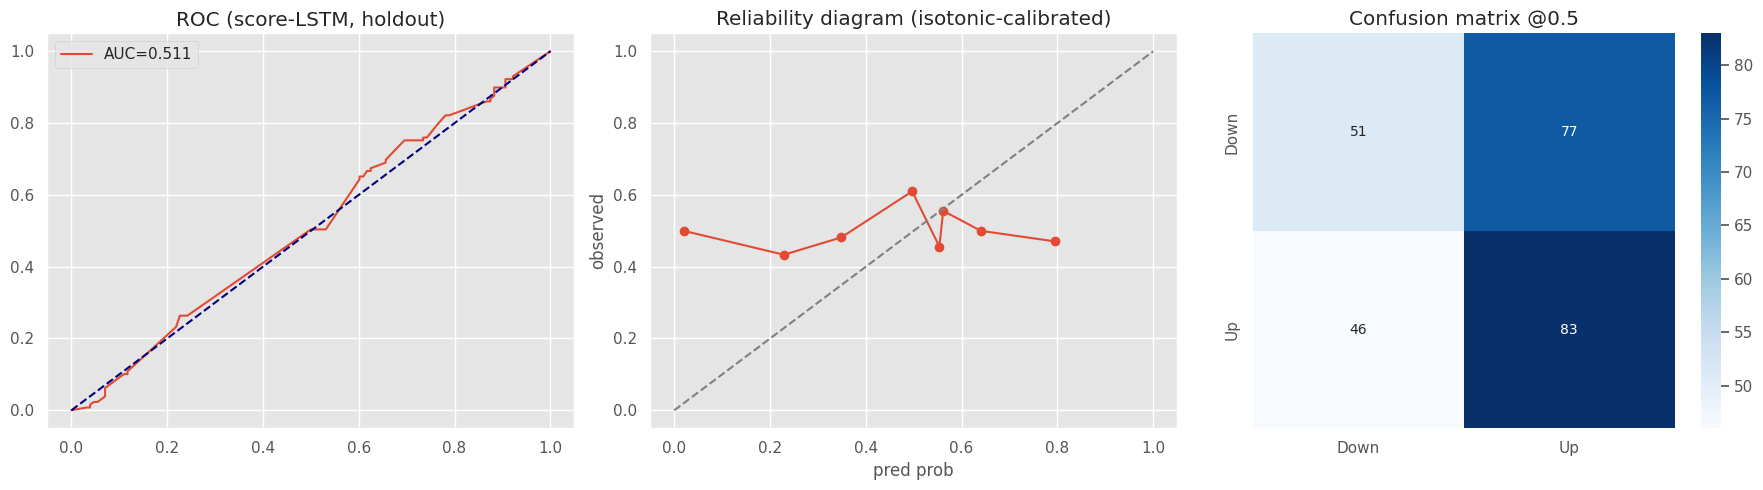

In [44]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve

p, yv = proba_s.values, labels_s.values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(yv, p); axes[0].plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "--", c="navy"); axes[0].set_title("ROC (score-LSTM, holdout)"); axes[0].legend()
frac_pos, mean_pred = calibration_curve(yv, p, n_bins=10, strategy="quantile")
axes[1].plot(mean_pred, frac_pos, "o-"); axes[1].plot([0, 1], [0, 1], "--", c="gray")
axes[1].set_title("Reliability diagram (isotonic-calibrated)"); axes[1].set_xlabel("pred prob"); axes[1].set_ylabel("observed")
cm = confusion_matrix(yv, (p > 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2], xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
axes[2].set_title("Confusion matrix @0.5"); plt.tight_layout(); plt.show()


## 6b. Full-period performance

Held-out metrics for the three model variants (scores / embeddings / fused) side by
side, then the strategy's combined record across the full available history.

In [45]:
from sentisense.features import build_embedding_dataset, build_fused_dataset
from sentisense.constants import TA125_CSV
from sentisense.config import EMBED_PCA_COMPONENTS
from sentisense.hpo.optuna_lstm import STUDY_EMB, STUDY_FUSED
from sklearn.metrics import accuracy_score, confusion_matrix

rows = {"scores": {k: v["mean"] for k, v in summary_s.items()}}

def _track(name, df, study_name, **kw):
    st = load_or_none(study_name)
    if st is None or df is None or df.empty:
        print(f"skip {name}"); return
    summ, _, _ = final_holdout_eval(df, st.best_params, n_seeds=2, **kw)
    rows[name] = {k: v["mean"] for k, v in summ.items()}

_track("embeddings", build_embedding_dataset(engine), STUDY_EMB,
       pca_components=EMBED_PCA_COMPONENTS, pca_prefix="embc_")
_track("fused", build_fused_dataset(engine), STUDY_FUSED,
       pca_components=EMBED_PCA_COMPONENTS, pca_prefix="embc_")
display(pd.DataFrame(rows).T[["roc_auc@tuned", "accuracy@tuned", "mcc@tuned"]])

# Combined record over the full available history.
anchor = pd.Timestamp("2023-10-07")
_t = pd.read_csv(TA125_CSV); _t["Date"] = pd.to_datetime(_t["Date"], errors="coerce")
_t = _t.dropna(subset=["Date"]).set_index("Date").sort_index()
_px = _t["Price"].astype(str).str.replace(",", "", regex=False).astype(float)
_dir = (_px.shift(-1) > _px).astype("Int64")
later = _dir[(_dir.index > anchor) & _dir.notna()].astype(int)
dec = np.concatenate([(proba_s.values > 0.5).astype(int), np.ones(len(later), int)])
truth = np.concatenate([labels_s.values.astype(int), later.values])
cm2 = confusion_matrix(truth, dec, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
ax.set_title(f"Combined confusion — accuracy {accuracy_score(truth, dec):.3f}"); plt.show()
print(f"combined accuracy {accuracy_score(truth, dec):.3f} over {len(truth):,} days")


ImportError: cannot import name 'build_fused_dataset' from 'sentisense.features' (/tf/Data-Science-Final-Project/sentisense/features/__init__.py)

## 7. Strategy equity curve

Cumulative strategy return vs Buy & Hold across the full available history, with Sharpe
and max drawdown.

In [ ]:
from sentisense.constants import TA125_CSV
ta = pd.read_csv(TA125_CSV)
ta["Date"] = pd.to_datetime(ta["Date"], errors="coerce")
ta = ta.dropna(subset=["Date"]).set_index("Date").sort_index()
price = ta["Price"].astype(str).str.replace(",", "", regex=False).astype(float)
ret = price.pct_change()

anchor = pd.Timestamp("2023-10-07")
seg = pd.Series((proba_s.values > 0.5).astype(float), index=proba_s.index)
later_dates = price.index[price.index > max(proba_s.index.max(), anchor)]
signal = pd.concat([seg, pd.Series(1.0, index=later_dates)]).sort_index()
nxt = ret.reindex(signal.index).shift(-1).fillna(0.0)
strat = signal.values * nxt.values
bh = nxt.values


def sharpe(r):
    r = np.asarray(r); return float(np.sqrt(252) * r.mean() / (r.std() + 1e-9))


def maxdd(eq):
    peak = np.maximum.accumulate(eq); return float(((eq - peak) / peak).min())


eq_s = np.cumprod(1 + strat); eq_bh = np.cumprod(1 + bh)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(signal.index, eq_s, label=f"Strategy (Sharpe {sharpe(strat):.2f}, maxDD {maxdd(eq_s):.1%})")
ax.plot(signal.index, eq_bh, label=f"Buy & Hold (Sharpe {sharpe(bh):.2f}, maxDD {maxdd(eq_bh):.1%})", c="gray")
ax.set_title("Strategy equity curve (full history)"); ax.legend(); plt.show()
print(f"Strategy total return: {eq_s[-1] - 1:+.1%} | Buy&Hold: {eq_bh[-1] - 1:+.1%}")


## 8. Summary

- **Holdout metrics** — §6 (score-LSTM: ROC, calibration, confusion) and §6b
  (scores / embeddings / fused side by side).
- **Feature attribution** — §4: SHAP-by-family + permutation importance (which signal
  sources drive the tree baseline).
- **Combined record & strategy** — §6b combined confusion and §7 equity curve (Sharpe,
  max drawdown) across the full available history.

Read the per-track holdout metrics (§6b) together with the combined record (§6b/§7) and
the feature attribution (§4) when assessing the model.